# When does synthetic data help?

Synthetic data is often assumed to be a free accuracy boost: generate more series, get a better model. The two benchmarks on this page bound that claim. Adding synthetic series to a model that already has enough real data does not reliably lower error. Pretraining on synthetic data and applying it zero-shot does lower error for series with little history. Synthetic data is also useful for coverage, robustness testing, and privacy, which accuracy numbers on a single panel do not capture.

::: {.callout-important}
## Summary

Two paired, multi-seed results:

- **Augmentation is neutral.** On M4 Monthly, adding `SynAugment` series to a properly-scaled global forecaster did not reliably beat the observed data alone. Across panel sizes 3–30 and 20 seeds the win rate sat at a coin flip with no significant effect.
- **Zero-shot pretraining helps cold-start.** On M3 Monthly, a model pretrained on synthetic data and used zero-shot beat training from scratch by ~20% when each series kept only ~48 months of history, in every one of 10 seeds. The edge reversed once history was ample.

Synthetic data lowers error where the model is short of data, not where it already has enough.
:::

## The benchmark

We sample panels of `n` M4 Monthly series and compare a global gradient-boosted forecaster (`HistGradientBoostingRegressor` via MLForecast, with per-series standardization — the correct configuration for M4's varied scales) trained on:

- **observed** — the real series only;
- **augmented** — real series plus `SynAugment` counterparts, fit on the training split only (leakage-safe).

We forecast the official 18-month M4 holdout and score seasonal MASE, paired within each seed. The full sweep (20 seeds) lives in [`benchmarks/benchmark_augmentation.py`](https://github.com/Nixtla/synforecast/blob/main/benchmarks/benchmark_augmentation.py); here we load its committed summary.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

summary_path = Path("benchmarks/data/augmentation_summary.json")
if not summary_path.exists():
    summary_path = Path("../../benchmarks/data/augmentation_summary.json")
summary = json.loads(summary_path.read_text())

table = pd.DataFrame(
    {
        "series in panel": e["n_series"],
        "observed MASE": round(e["observed_mase"], 3),
        "augmented MASE": round(e["augmented_mase"], 3),
        "improvement %": round(e["mean_dmase_pct"], 1),
        "win rate": f"{e['win_rate']:.0%}",
        "Wilcoxon p": round(e["wilcoxon_p"], 3),
    }
    for e in summary["by_size"]
)
print(f"{summary['dataset']} | {summary['model']} | {summary['seeds']} seeds")
table

M4 Monthly (official 18-month holdout) | HistGradientBoostingRegressor via MLForecast, per-series scaling | 20 seeds


,series in panel,observed MASE,augmented MASE,improvement %,win rate,Wilcoxon p
0,3,1.444,1.326,4.7,60%,0.143
1,5,1.336,1.393,-5.9,45%,0.784
2,10,1.467,1.409,2.2,60%,0.261
3,30,1.301,1.248,2.9,65%,0.294


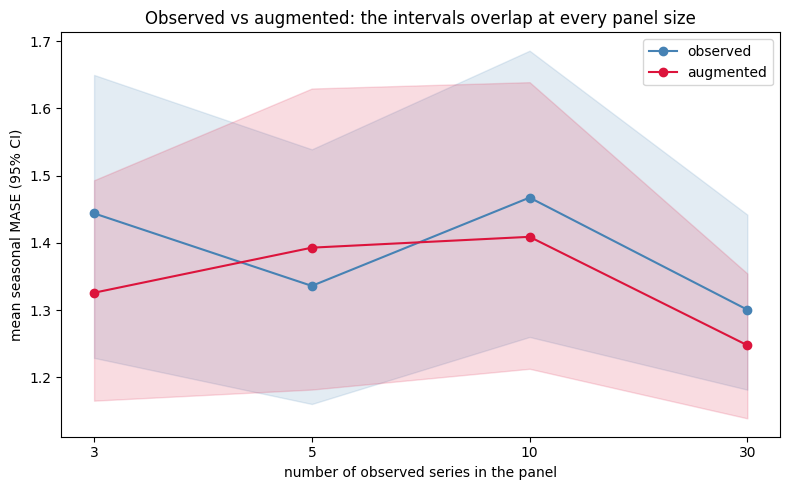

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sizes = [e["n_series"] for e in summary["by_size"]]
xs = range(len(sizes))
for cond, color in [("observed", "steelblue"), ("augmented", "crimson")]:
    means = [e[f"{cond}_mase"] for e in summary["by_size"]]
    los = [e[f"{cond}_ci"][0] for e in summary["by_size"]]
    his = [e[f"{cond}_ci"][1] for e in summary["by_size"]]
    ax.plot(list(xs), means, marker="o", color=color, label=cond)
    ax.fill_between(list(xs), los, his, color=color, alpha=0.15)
ax.set_xticks(list(xs))
ax.set_xticklabels([str(n) for n in sizes])
ax.set(xlabel="number of observed series in the panel",
       ylabel="mean seasonal MASE (95% CI)",
       title="Observed vs augmented: the intervals overlap at every panel size")
ax.legend()
plt.tight_layout()
plt.show()

The confidence intervals overlap everywhere and the paired win rate never departs meaningfully from 50%. Two caveats about what the result does and does not show:

::: {.callout-warning}
## Scope of the result

- **This is not evidence that synthetic data is useless.** It shows that augmenting a model that already has enough signal does not lower error. A gradient-boosted global model with a few full M4 histories is not short of data.
- **A win is easy to manufacture.** An earlier version of this benchmark showed a large apparent gain that came from an unscaled baseline, where augmentation was compensating for the model's poor scale handling, and from too few seeds. With per-series scaling and 20 seeds the effect vanished. Treat augmentation benchmarks that omit either with suspicion.
:::

## Other uses

Synthetic data is useful in ways a single-panel accuracy number does not measure:

::: {.callout-tip}
## Four use cases

- **Coverage and diversity.** [`generate_series`](../getting-started/quickstart) and the [balanced pool](balanced_pool) span behaviors — volatility clustering, long memory, intermittency, chaos — that no single real dataset contains. Useful for stress-testing a pipeline and for pretraining breadth.
- **Robustness testing.** Inject [anomalies](anomalies), [changepoints](changepoints), and [missingness](missingness) with known ground truth to measure how a model degrades.
- **Privacy.** Share a reproducible, statistically-similar panel without exposing proprietary series.
- **Pretraining at scale.** The diversity-targeted generators — [TSI](../generators/pretraining/tsi), [TCM](../generators/pretraining/tcm), and [KernelSynth](../generators/pretraining/kernel_synth) — exist to pretrain models that transfer to unseen series. The section below measures this: a synthetic-pretrained model used zero-shot beats training from scratch when the real history is short.
:::

Coverage is straightforward to check. One call yields a panel of visibly different data-generating processes:

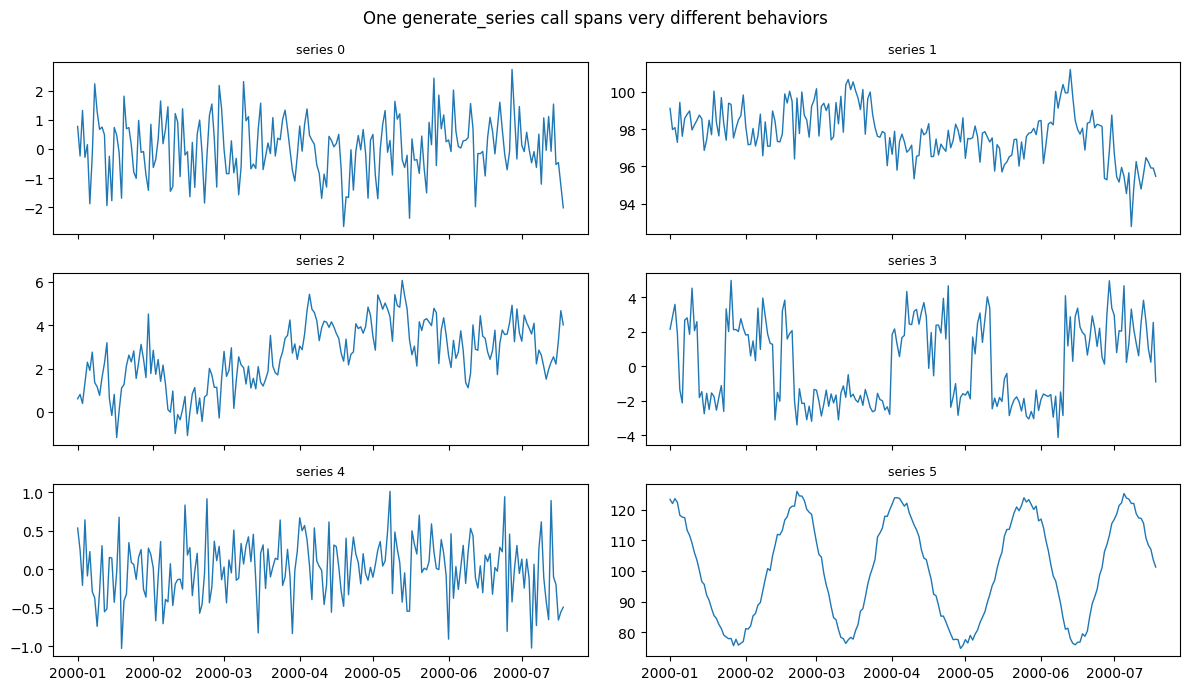

In [ ]:
from synforecast import generate_series

pool = generate_series(
    n_series=6, freq="D", min_length=200, max_length=200, engine="polars", seed=7
)
import polars as pl

fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
for ax, uid in zip(axes.flat, pool["unique_id"].unique(maintain_order=True).to_list()):
    s = pool.filter(pl.col("unique_id") == uid)
    ax.plot(s["ds"], s["y"], linewidth=1)
    ax.set_title(f"series {uid}", fontsize=9)
fig.suptitle("One generate_series call spans very different behaviors")
plt.tight_layout()
plt.show()

## Pretraining: a cold-start win

The augmentation result above concerns a model that already has enough real data. Pretraining tests the opposite case: a model with too little real history to learn from. We pretrain a small NHITS on a synthetic corpus from [`pretraining_pool()`](balanced_pool), then forecast M3 Monthly series while varying how much history each series keeps, from 48 months up to the full record. The corpus is generated independently and never sees M3.

Three ways to use the pretrained model, compared against the same 18-month holdout:

- **from-scratch** — ignore pretraining, train NHITS on the real history alone.
- **zero-shot** — apply the synthetic-pretrained model directly, no real training.
- **pretrain + fine-tune** — continue training it on the real history at a reduced learning rate.

In [ ]:
pt_path = Path('benchmarks/data/pretraining_summary.json')
if not pt_path.exists():
    pt_path = Path('../../benchmarks/data/pretraining_summary.json')
pt = json.loads(pt_path.read_text())


def _hist_label(h):
    return 'full' if h >= 9999 else f'{h} mo'


pt_table = pd.DataFrame(
    {
        'history kept': _hist_label(e['hist_len']),
        'from-scratch MASE': round(e['from_scratch_mase'], 3),
        'zero-shot MASE': round(e['zero_shot_mase'], 3),
        'pretrain+ft MASE': round(e['pretrain_ft_mase'], 3),
        'zero-shot improve %': round(e['zero_shot_mean_improve_pct'], 1),
        'zero-shot win rate': f"{e['zero_shot_win_rate']:.0%}",
        'zero-shot p': f"{e['zero_shot_wilcoxon_p']:.1e}",
    }
    for e in pt['by_hist_len']
)
print(f"{pt['dataset']} | {pt['model']} | {pt['seeds']} seeds x "
      f"{pt['n_series']} series")
pt_table

M3 Monthly (last 18 months held out) | NHITS via NeuralForecast, per-series standardization | 10 seeds x 300 series


,history kept,from-scratch MASE,zero-shot MASE,pretrain+ft MASE,zero-shot improve %,zero-shot win rate,zero-shot p
0,48 mo,1.632,1.300,1.621,20.3,100%,2.0e-03
1,72 mo,1.441,1.288,1.435,10.6,100%,2.0e-03
2,108 mo,1.308,1.405,1.322,-7.6,10%,3.9e-03
3,full,1.238,1.395,1.261,-12.8,0%,2.0e-03


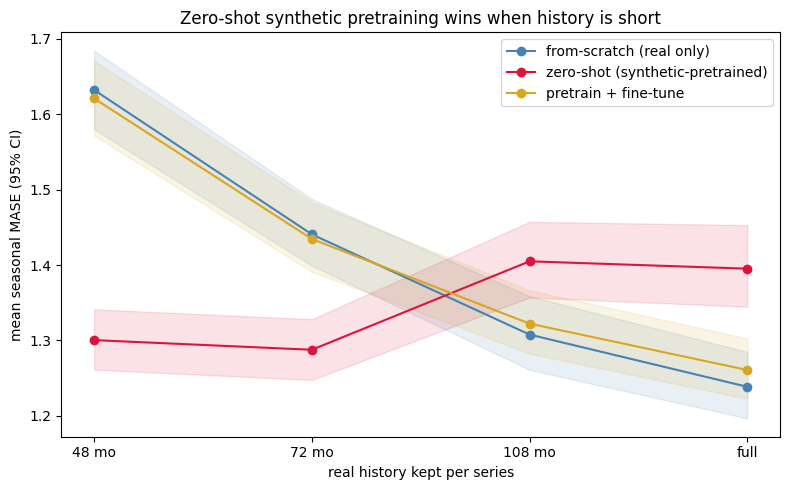

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = [_hist_label(e['hist_len']) for e in pt['by_hist_len']]
xs = range(len(labels))
conds = [
    ('from_scratch', 'from-scratch (real only)', 'steelblue'),
    ('zero_shot', 'zero-shot (synthetic-pretrained)', 'crimson'),
    ('pretrain_ft', 'pretrain + fine-tune', 'goldenrod'),
]
for key, label, color in conds:
    means = [e[f'{key}_mase'] for e in pt['by_hist_len']]
    los = [e[f'{key}_ci'][0] for e in pt['by_hist_len']]
    his = [e[f'{key}_ci'][1] for e in pt['by_hist_len']]
    ax.plot(list(xs), means, marker='o', color=color, label=label)
    ax.fill_between(list(xs), los, his, color=color, alpha=0.12)
ax.set_xticks(list(xs))
ax.set_xticklabels(labels)
ax.set(xlabel='real history kept per series',
       ylabel='mean seasonal MASE (95% CI)',
       title='Zero-shot synthetic pretraining wins when history is short')
ax.legend()
plt.tight_layout()
plt.show()

With only 48 months of history the zero-shot model cuts seasonal MASE by about 20% against training from scratch, winning in all 10 seeds (p = 0.002, the smallest value a 10-seed paired test can produce). The from-scratch model has too few windows to learn the seasonality the pretrained model already carries. The gap narrows as history grows and reverses past roughly 100 months, where a from-scratch model has enough data and wins outright.

Fine-tuning lands in between and rarely wins: on short histories it drags the pretrained model toward the data-starved fit, and on long ones it cannot beat from-scratch. Use zero-shot for cold-start series and from-scratch once history is ample.

## Reproduce

```bash
uv run python benchmarks/benchmark_augmentation.py --seeds 20 \
    --save benchmarks/data/augmentation_results.csv \
    --save-summary benchmarks/data/augmentation_summary.json
```

Use `--quick` for a fast smoke run. The script is model- and dataset-agnostic enough to re-point at another panel. To decide whether augmentation helps on a given problem, run the same paired, multi-seed comparison on that data, never on the final holdout.

And the pretraining sweep (needs a GPU):

```bash
uv run python benchmarks/benchmark_pretraining.py --seeds 10 \
    --save-summary benchmarks/data/pretraining_summary.json
```